# Load in the libs
### The function calls are all the same it is just the library that changes hence you only change the import library line

In [ ]:
# Python Libs
import numpy as np
import matplotlib.pyplot as plt
import time
plt.style.use('dark_background')

# import pwi_inst.hardware.Cameras.FirstlightCameras.FirstLightCblue2 as CamLib
# import pwi_inst.hardware.Cameras.FirstlightCameras.FirstLightCred3_2Lite as CamLib
import pwi_inst.hardware.Cameras.FLIRPointGreyCameras.FLIR_PointGrey as CamLib



In [2]:
%load_ext autoreload
%aimport pwi_inst.hardware.Cameras.FLIRPointGreyCameras.flir_flycapture2_ctypes
%aimport pwi_inst.hardware.Cameras.FLIRPointGreyCameras.FLIR_PointGrey
%aimport pwi_inst.hardware.Cameras.FirstlightCameras.FirstLightCblue2
%autoreload 1


In [3]:
Camobject = CamLib.CameraObject(CameraIdx=0,verbose=True)


1 cameras detected:
0: Andor CB2 7.1#01-00001f8a4c91#MatroxCXP-Dev_0
Using camera 0
AcquisitionMode: Continuous | TriggerMode: Off | TriggerSource: Line0 | TriggerSelector: FrameStart


In [7]:
del Camobject

# Set to Continuous mode and get a frame
### Note that the buffer number will jump around a but as the camera is in contious mode

100.00151062011719


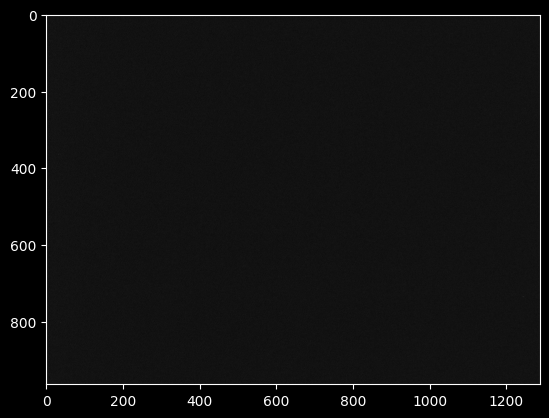

In [5]:
Camobject.SetContinuousMode()
Camobject.SetExposureTime(100)
exp=Camobject.GetExposureTime()
print(exp)
frame=Camobject.GetFrame()
plt.imshow(frame, cmap='gray')

# Set the camera to single capature mode and get a frame then change exposure and get another frame
### Note that you need to burn through some frames in software trigger mode to see the feature get updated

In [19]:
Camobject.SetSoftwareTriggerMode()
frame=Camobject.GetFrame()


Exposure time too low, setting to minimum: 0.04559755325317383


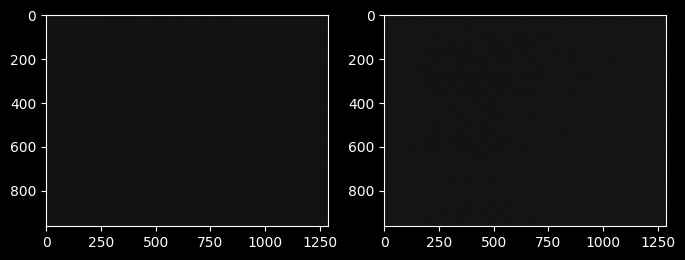

In [ ]:
Camobject.SetSoftwareTriggerMode()

Camobject.SetExposureTime(0)
for i in range(3):
    frame=Camobject.GetFrame()
frame_1=Camobject.GetFrame()
print(Camobject.GetFrameID())

Camobject.SetExposureTime(100)
for i in range(3):
    frame=Camobject.GetFrame()
frame_2=Camobject.GetFrame()
print(Camobject.GetFrameID())



plt.figure(1,figsize=(8,8))
plt.subplot(1,2,1)
plt.imshow(frame_1, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(frame_2, cmap='gray')


# Change the region of intrest

(150, 200, 8, 256)
(0, 0, 1288, 964)


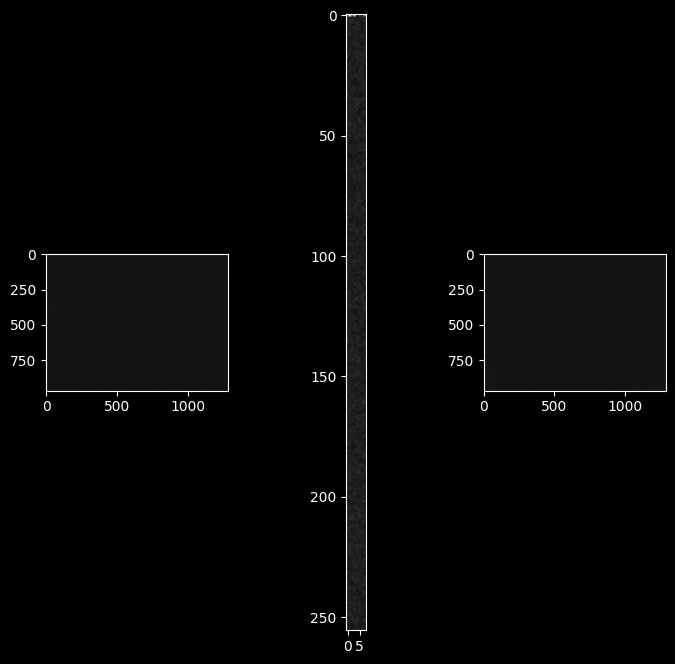

In [8]:
Camobject.SetContinuousMode()

#current frame
frame_1=Camobject.GetFrame()

# New region of interest (ROI) geometry
Camobject.SetROI(150,200,7,256,enable=True)
frame_2=Camobject.GetFrame()
print(Camobject.GetROI())

# Reset to full frame
Camobject.SetROI(512,512,256,8,enable=False)
frame_3=Camobject.GetFrame()
print(Camobject.GetROI())

plt.figure(1,figsize=(8,8))
plt.subplot(1,3,1)  
plt.imshow(frame_1, cmap='gray')
plt.subplot(1,3,2)
plt.imshow(frame_2, cmap='gray')
plt.subplot(1,3,3)
plt.imshow(frame_3, cmap='gray')

# hardware trigger tests


In [5]:
Camobject.SetHardwareTriggerMode()

AcquisitionMode: Continuous | TriggerMode: On | TriggerSource: Line0 | TriggerSelector: FrameStart


In [6]:
Camobject.SetSoftwareTriggerMode()

AcquisitionMode: Continuous | TriggerMode: On | TriggerSource: Software | TriggerSelector: FrameStart


In [2]:
import numpy as np
from datetime import datetime
import time

import pwi_inst.hardware.DAQ_Controller.NI_DAQ as DAQLib

# Select DAQ model to use
daq_model =  'ni_daq' #or 'mcc_daq'

# Set DAQ parameters
n_channels = 2 # number of DAQ channels
refresh_rate = 0.05
device_number = 0 # board number for MCC DAQ or device number for NI DAQ (e.g. 0="Dev1")

## Set initial voltages for each channel (V) [tip, tilt, attn]
init_volts = [-0.5, 6, 0]

## If True, voltages will return to zero when DAQ is shut down at end of script
zero_daq = False


# Initialize DAC controller
DAC_Controller = DAQLib.DAQObject(RefreshRate=refresh_rate,
                                    deviceNum=device_number,
                                    ChannelCount=n_channels)





DaqNotFoundError: Could not find an installation of NI-DAQmx. Please ensure that NI-DAQmx is installed on this machine or contact National Instruments for support.

In [ ]:

# Set channel voltages to initial values
for ch in range(n_channels):
    DAC_Controller.SetVoltage(channel=ch, voltage=init_volts[ch])

time.sleep(1) # hold voltages for 1 second before shutting down

# Release the board and zero channels if required
DAC_Controller.shutdown(zero=zero_daq)
